In [ ]:
import datetime
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score 
from sklearn.preprocessing import LabelEncoder
import math
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier 
from sklearn.linear_model import LogisticRegression
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import SGD
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
train_data = pd.read_csv("fraudTrain.csv")
test_data = pd.read_csv("fraudTest.csv")

In [3]:
train_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
test_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [7]:
def preprocces(df):
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df['trans_date_year'] = pd.to_datetime(df['trans_date_trans_time']).dt.year
    df['trans_date_month'] = pd.to_datetime(df['trans_date_trans_time']).dt.month
    df['trans_date_day'] = pd.to_datetime(df['trans_date_trans_time']).dt.day

    df["dob_trans_time"] = pd.to_datetime(df["dob"])
    df['dob_year'] = pd.to_datetime(df['dob']).dt.year
    df['dob_month'] = pd.to_datetime(df['dob']).dt.month
    df['dob_day'] = pd.to_datetime(df['dob']).dt.day
    
    df.drop(columns=['Unnamed: 0','cc_num','first', 'last', 'street', 'city', 'state', 'trans_date_trans_time', 'dob', 'dob_trans_time', 'zip', 'trans_num'],inplace=True)

    df.dropna(inplace=True, ignore_index=True)

    encoder = LabelEncoder()
    df["merchant"] = encoder.fit_transform(df["merchant"])
    df["category"] = encoder.fit_transform(df["category"])
    df["gender"] = encoder.fit_transform(df["gender"])
    df["job"] = encoder.fit_transform(df["job"])
    return df

In [8]:
train_data = preprocces(train_data)
train_data.head()

,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,trans_date_year,trans_date_month,trans_date_day,dob_year,dob_month,dob_day
0,514,8,4.97,0,36.0788,-81.1781,3495,370,1325376018,36.011293,-82.048315,0,2019,1,1,1988,3,9
1,241,4,107.23,0,48.8878,-118.2105,149,428,1325376044,49.159047,-118.186462,0,2019,1,1,1978,6,21
2,390,0,220.11,1,42.1808,-112.2620,4154,307,1325376051,43.150704,-112.154481,0,2019,1,1,1962,1,19
3,360,2,45.00,1,46.2306,-112.1138,1939,328,1325376076,47.034331,-112.561071,0,2019,1,1,1967,1,12
4,297,9,41.96,1,38.4207,-79.4629,99,116,1325376186,38.674999,-78.632459,0,2019,1,1,1986,3,28


In [9]:
test_data = preprocces(test_data)
test_data.head()

,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,trans_date_year,trans_date_month,trans_date_day,dob_year,dob_month,dob_day
0,319,10,2.86,1,33.9659,-80.9355,333497,275,1371816865,33.986391,-81.200714,0,2020,6,21,1968,3,19
1,591,10,29.84,0,40.3207,-110.4360,302,392,1371816873,39.450498,-109.960431,0,2020,6,21,1990,1,17
2,611,5,41.28,0,40.6729,-73.5365,34496,259,1371816893,40.495810,-74.196111,0,2020,6,21,1970,10,21
3,222,9,60.05,1,28.5697,-80.8191,54767,407,1371816915,28.812398,-80.883061,0,2020,6,21,1987,7,25
4,292,13,3.19,1,44.2529,-85.0170,1126,196,1371816917,44.959148,-85.884734,0,2020,6,21,1955,7,6


In [10]:
numeric_df = train_data.select_dtypes(include=["int64", "float64"])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outliers.sum().sort_values(ascending=False)

city_pop      242674
amt            67290
long           49922
merch_long     41994
is_fraud        7506
merch_lat       4967
lat             4679
merchant           0
gender             0
category           0
job                0
unix_time          0
dtype: int64

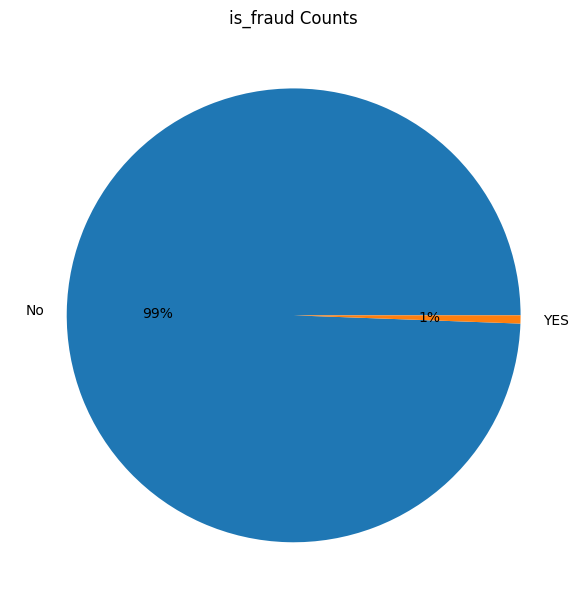

In [11]:
exit_counts = train_data["is_fraud"].value_counts()
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) 
plt.pie(exit_counts, labels=["No", "YES"], autopct="%0.0f%%")
plt.title("is_fraud Counts")
plt.tight_layout()
plt.show()

In [12]:
def distribution_plot(numeric_df, data):
    numeric_cols = numeric_df.columns
    n = len(numeric_cols)
    cols_per_row = 4
    rows = math.ceil(n / cols_per_row)
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3.5))
    axes = axes.flatten()
    palette = sns.color_palette("crest", n)
    for i, col in enumerate(numeric_cols):
        sns.histplot(train_data[col], bins=20, kde=True, ax=axes[i], color=palette[i])
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel("")
    for ax in axes[n:]:
        ax.remove()
    fig.suptitle(f"Distributions of {data} data", fontsize=16, y=1.02)
    fig.tight_layout()
    plt.show()

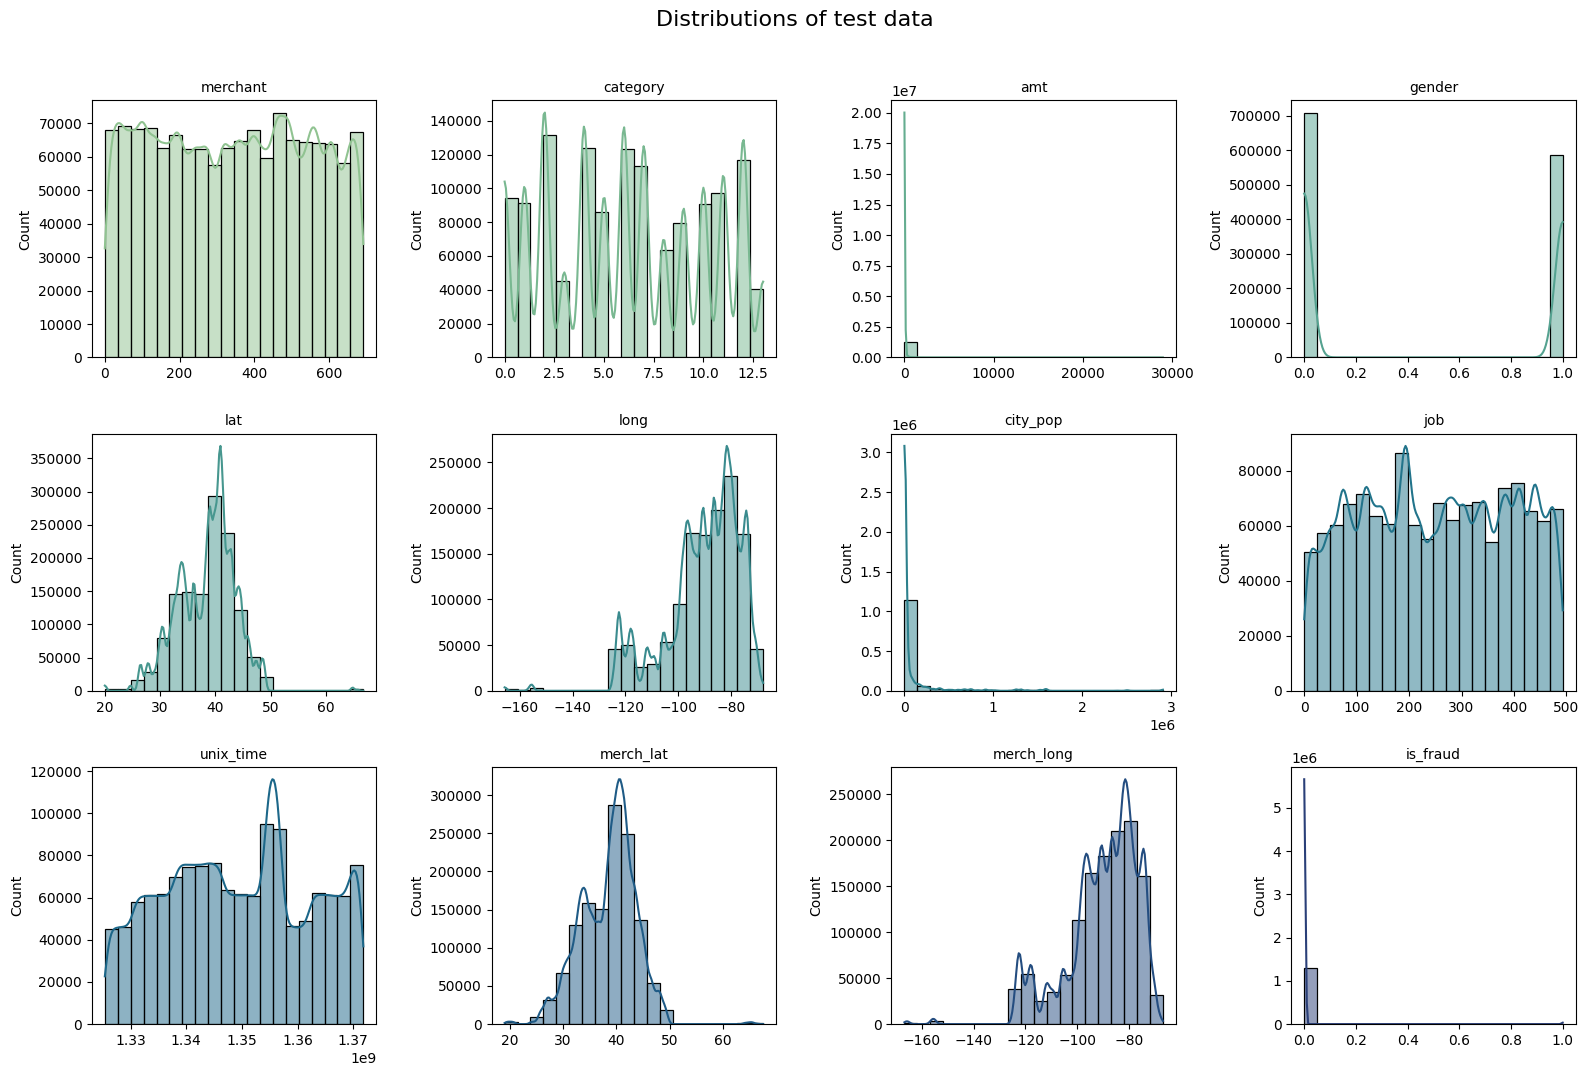

In [13]:
numeric_df = test_data.select_dtypes(include=["int64", "float64"])
distribution_plot(numeric_df, 'test')

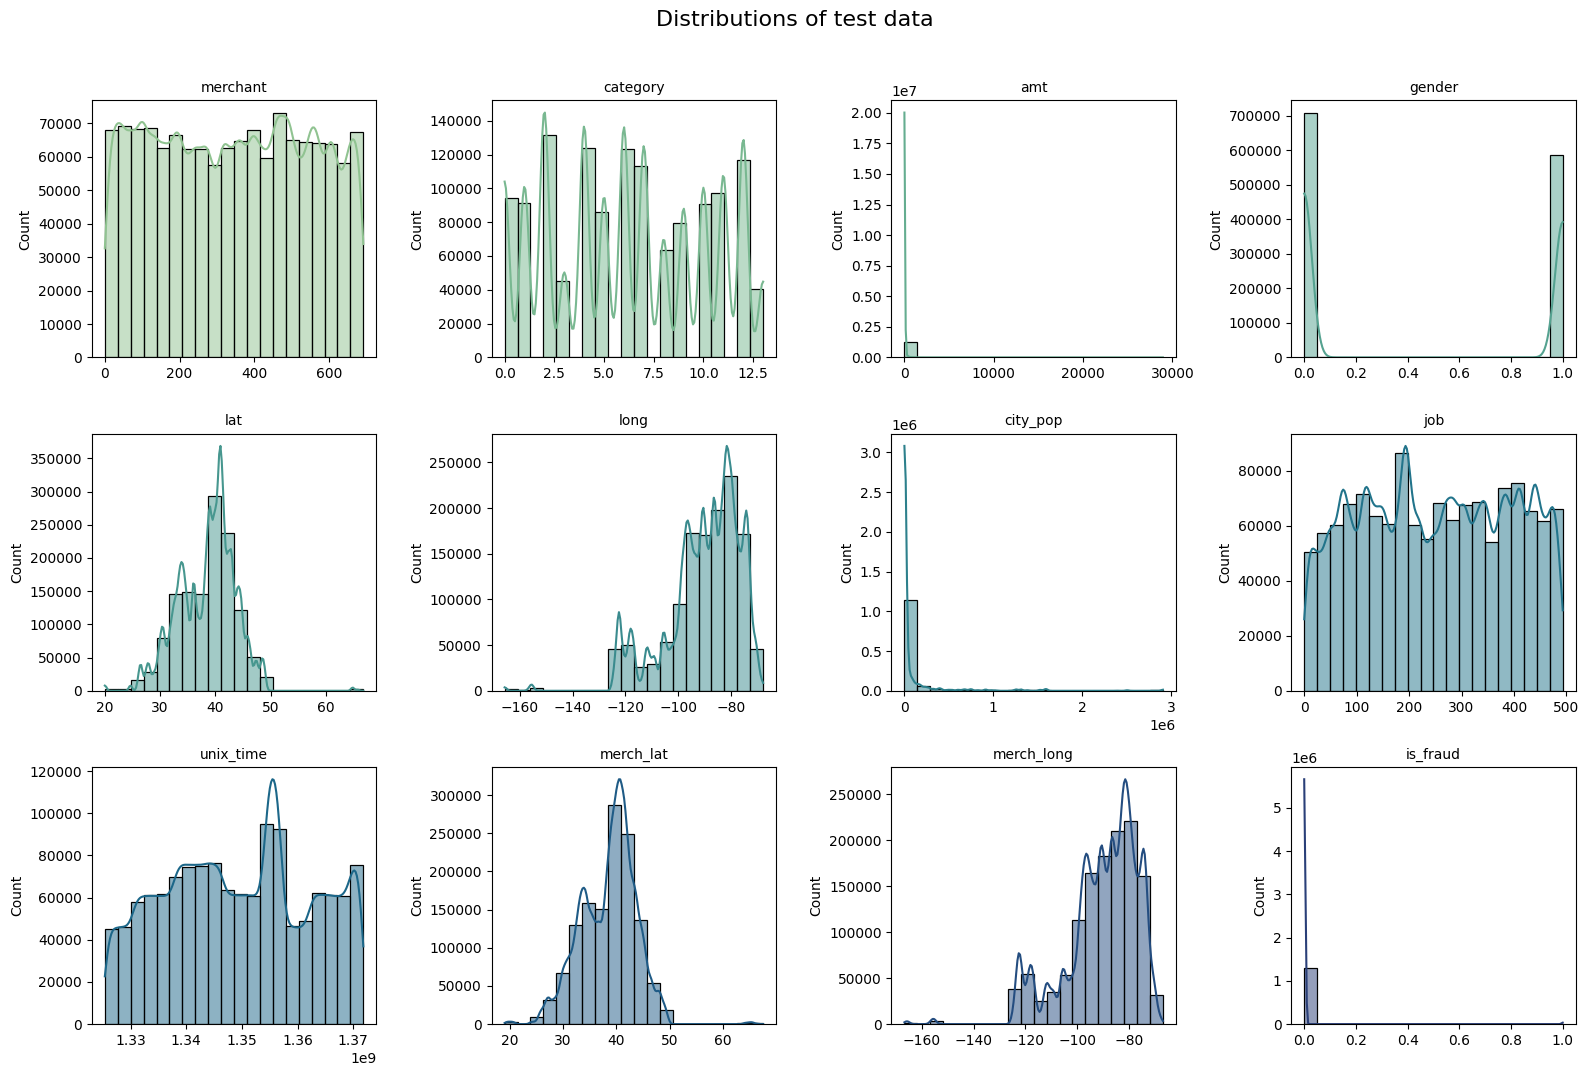

In [14]:
numeric_df = test_data.select_dtypes(include=["int64", "float64"])
distribution_plot(numeric_df, 'test')

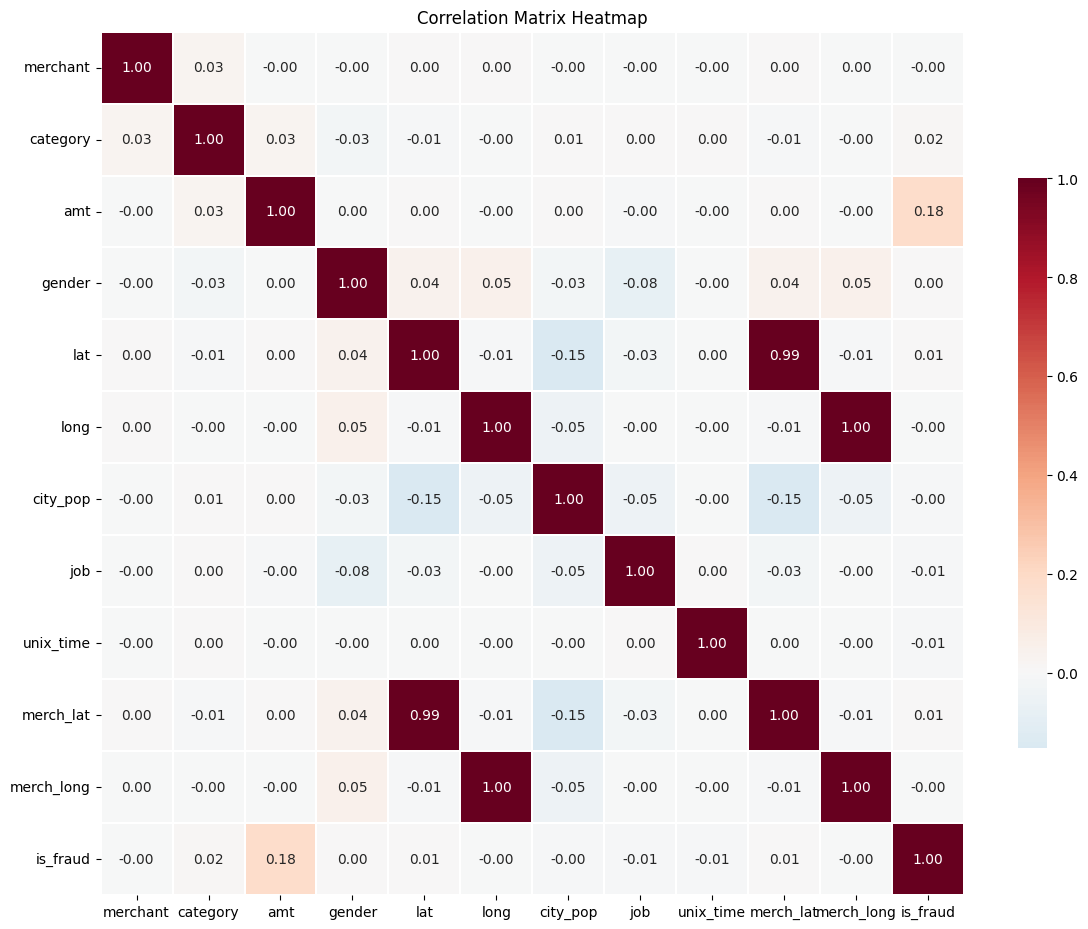

In [15]:
corr_matrix = test_data[numeric_df.columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    square=True,
    cbar_kws={"shrink": 0.6},
)
plt.xticks(rotation=0, ha="center")
plt.yticks(rotation=0)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

In [16]:
X = train_data.drop(columns=["is_fraud"], inplace = False)
Y = train_data["is_fraud"]

In [111]:
smote = SMOTE(sampling_strategy=0.4, random_state=42)
X_res, Y_res = smote.fit_resample(X, Y)

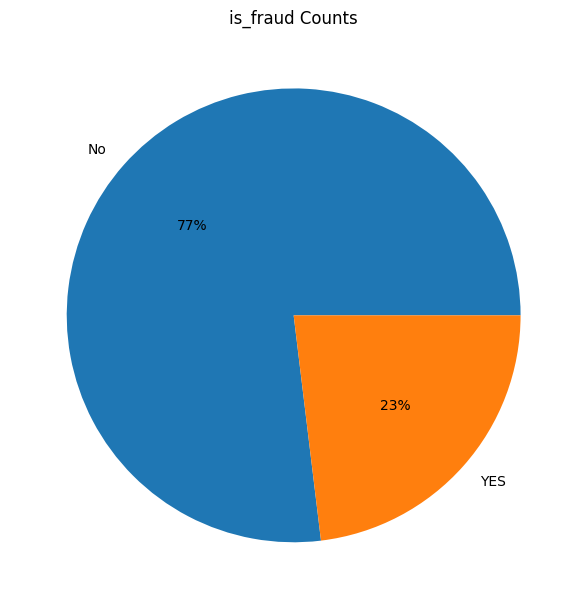

In [70]:
exit_counts = Y_res.value_counts()
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) 
plt.pie(exit_counts, labels=["No", "YES"], autopct="%0.0f%%")
plt.title("is_fraud Counts")
plt.tight_layout()
plt.show()

In [62]:
model = RandomForestClassifier(
            n_estimators=300, 
            class_weight='balanced',
            random_state=42, 
            n_jobs=-1, 
        )

model.fit(X_res, Y_res)

KeyboardInterrupt: 

In [112]:
X_test = test_data.drop(columns=["is_fraud"], inplace = False)
Y_test = test_data["is_fraud"]

In [21]:
y_pred = model.predict(X_test)

In [22]:
accuracy = accuracy_score(test_data['is_fraud'],y_pred)
precision = precision_score(test_data['is_fraud'],y_pred)
recall = recall_score(test_data['is_fraud'],y_pred)
f1 = f1_score(test_data['is_fraud'],y_pred)
roc_auc = roc_auc_score(test_data['is_fraud'],y_pred)
conf_matrix = confusion_matrix(test_data['is_fraud'],y_pred)

In [23]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

Accuracy: 0.9963
Precision: 0.5409
Recall: 0.1944
F1 Score: 0.2860
ROC AUC Score: 0.5969


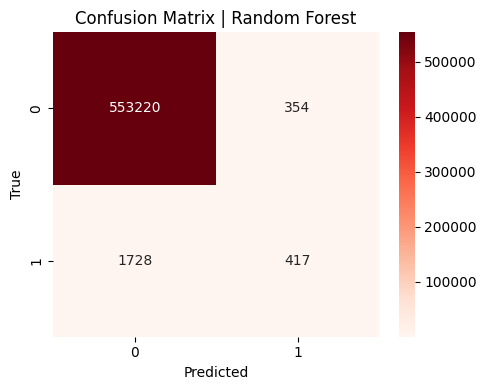

In [24]:
plt.figure(figsize=(5, 4)) 
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds") 
plt.title("Confusion Matrix | Random Forest") 
plt.xlabel("Predicted")  
plt.ylabel("True") 
plt.tight_layout() 
plt.show() 

In [71]:
xgb_model = XGBClassifier(
            n_estimators=400, 
            max_depth=4,  
            learning_rate=0.05, 
            subsample=0.9, 
            colsample_bytree=0.9,
            random_state=42, 
            n_jobs=-1,
        )

xgb_model.fit(X_res, Y_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [72]:
y_pred = xgb_model.predict(X_test)

In [73]:
xgb_accuracy = accuracy_score(test_data['is_fraud'],y_pred)
xgb_precision = precision_score(test_data['is_fraud'],y_pred)
xgb_recall = recall_score(test_data['is_fraud'],y_pred)
xgb_f1 = f1_score(test_data['is_fraud'],y_pred)
xgb_roc_auc = roc_auc_score(test_data['is_fraud'],y_pred)
xgb_conf_matrix = confusion_matrix(test_data['is_fraud'],y_pred)

In [75]:
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1 Score: {xgb_f1:.4f}")
print(f"ROC AUC Score: {xgb_roc_auc:.4f}")

Accuracy: 0.9865
Precision: 0.1947
Recall: 0.8000
F1 Score: 0.3132
ROC AUC Score: 0.8936


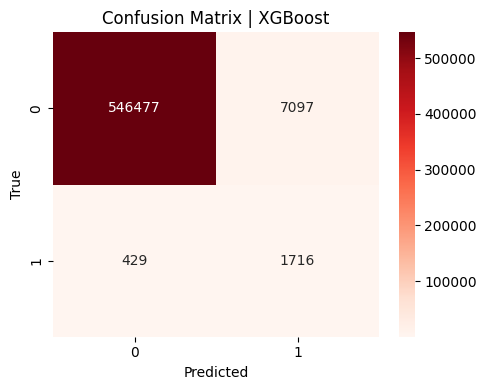

In [76]:
plt.figure(figsize=(5, 4)) 
sns.heatmap(xgb_conf_matrix, annot=True, fmt="d", cmap="Reds") 
plt.title("Confusion Matrix | XGBoost") 
plt.xlabel("Predicted")  
plt.ylabel("True") 
plt.tight_layout() 
plt.show() 

In [77]:
lr = LogisticRegression(max_iter=500)

lr.fit(X_res, Y_res)

LogisticRegression(max_iter=500)

In [78]:
lr_y_pred = lr.predict(X_test)

In [79]:
lr_accuracy = accuracy_score(test_data['is_fraud'], lr_y_pred)
lr_precision = precision_score(test_data['is_fraud'], lr_y_pred)
lr_recall = recall_score(test_data['is_fraud'], lr_y_pred)
lr_f1 = f1_score(test_data['is_fraud'], lr_y_pred)
lr_roc_auc = roc_auc_score(test_data['is_fraud'], lr_y_pred)
lr_conf_matrix = confusion_matrix(test_data['is_fraud'], lr_y_pred)

In [80]:
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(f"ROC AUC Score: {lr_roc_auc:.4f}")

Accuracy: 0.9810
Precision: 0.1115
Recall: 0.5646
F1 Score: 0.1863
ROC AUC Score: 0.7736


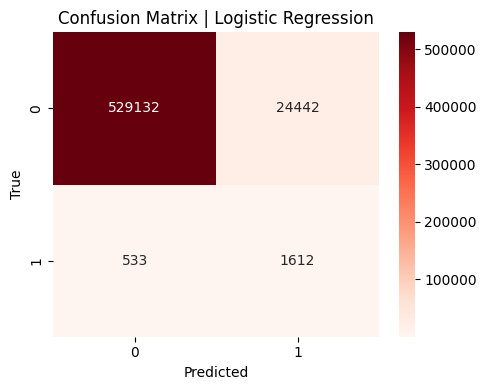

In [ ]:
plt.figure(figsize=(5, 4)) 
sns.heatmap(lr_conf_matrix, annot=True, fmt="d", cmap="Reds") 
plt.title("Confusion Matrix | Logistic Regression") 
plt.xlabel("Predicted")  
plt.ylabel("True") 
plt.tight_layout() 
plt.show() 

In [35]:
results_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Logistic Regression"],
    "Accuracy": [accuracy, xgb_accuracy, lr_accuracy],
    "Precision": [precision, xgb_precision, lr_precision],
    "Recall": [recall, xgb_recall, lr_recall],
    "F1 Score": [f1, xgb_f1, lr_f1],
    "ROC AUC Score": [roc_auc, xgb_roc_auc, lr_roc_auc]
})
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,Random Forest,0.996254,0.540856,0.194406,0.286008,0.596883
2,Logistic Regression,0.955058,0.061871,0.751515,0.114330,0.853681
1,XGBoost,0.946714,0.058621,0.850350,0.109681,0.898719


In [113]:
X_train = torch.from_numpy(X_res.to_numpy()).float()
y_train = torch.from_numpy(Y_res.to_numpy()).float().view(-1, 1)

X_test = torch.from_numpy(X_test.to_numpy()).float()
y_test = torch.from_numpy(Y_test.to_numpy()).float().view(-1, 1)

X_train.shape, y_train.shape , X_test.shape, y_test.shape

(torch.Size([1804836, 17]),
 torch.Size([1804836, 1]),
 torch.Size([555719, 17]),
 torch.Size([555719, 1]))

In [114]:
train_set = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)

In [115]:
test_set = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

In [116]:
num_samples, num_features = X_train.shape

num_classes = 2

nfl1 = 4 * num_features
nfl2 = 2 * num_features
model = nn.Sequential(
    nn.Linear(num_features, nfl1),
    nn.ReLU(),
    nn.Linear(nfl1, nfl2),
    nn.ReLU(),
    nn.Linear(nfl2, num_classes-1),
    nn.Sigmoid()
)
model.to(device)

Sequential(
  (0): Linear(in_features=17, out_features=68, bias=True)
  (1): ReLU()
  (2): Linear(in_features=68, out_features=34, bias=True)
  (3): ReLU()
  (4): Linear(in_features=34, out_features=1, bias=True)
  (5): Sigmoid()
)

In [117]:
loss_fn = nn.BCELoss()
loss_fn

BCELoss()

In [118]:
optimizer = SGD(model.parameters(), lr=0.0001, momentum=0.9)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)

In [119]:
loss_train_hist , acc_train_hist = [] , []

In [120]:
n_epochs = 10

for epoch in range(n_epochs):

  mean_loss_train, mean_loss_valid = 0, 0
  mean_acc_train, mean_acc_valid = 0, 0

  for iter, (x_batch, y_batch) in enumerate(train_loader):

    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device).view(-1, 1).float()

    y_hat = model(x_batch)

    loss = loss_fn(y_hat, y_batch)

    loss.backward()


    optimizer.step()
    optimizer.zero_grad()

    mean_loss_train += loss.item() * len(x_batch)
    mean_acc_train += torch.sum(y_hat.round() == y_batch).item()

  mean_loss_train = mean_loss_train / len(train_set)
  mean_acc_train = mean_acc_train / len(train_set)

  loss_train_hist.append(mean_loss_train)
  acc_train_hist.append(mean_acc_train)
  
  print(
  f"Epoch: {epoch}   "
  f"LossTrain: {mean_loss_train:.3}"
  f"AccTrain: {mean_acc_train:.3}"
  )

Epoch: 0   LossTrain: 71.4AccTrain: 0.286
Epoch: 1   LossTrain: 71.4AccTrain: 0.286
Epoch: 2   LossTrain: 71.4AccTrain: 0.286
Epoch: 3   LossTrain: 71.4AccTrain: 0.286
Epoch: 4   LossTrain: 71.4AccTrain: 0.286
Epoch: 5   LossTrain: 71.4AccTrain: 0.286
Epoch: 6   LossTrain: 71.4AccTrain: 0.286
Epoch: 7   LossTrain: 71.4AccTrain: 0.286
Epoch: 8   LossTrain: 71.4AccTrain: 0.286
Epoch: 9   LossTrain: 71.4AccTrain: 0.286


In [121]:
all_preds = []
all_targets = []

model.eval() 
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).view(-1, 1).float()
        y_hat = model(x_batch)
        
        _ , predicted = torch.max(y_hat, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

a  = accuracy_score(all_targets, all_preds)   
p = precision_score(all_targets, all_preds, average='macro')
r = recall_score(all_targets, all_preds, average='macro')
f1 = f1_score(all_targets, all_preds, average='macro')
mlp_confusion_matrix = confusion_matrix(all_targets, all_preds)
print(f"Accuracy: {a:.4f}, Precision: {p:.4f}, Recall: {r:.4f}, F1-Score: {f1:.4f}")

/home/norbert/.venvs/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.9961, Precision: 0.4981, Recall: 0.5000, F1-Score: 0.4990


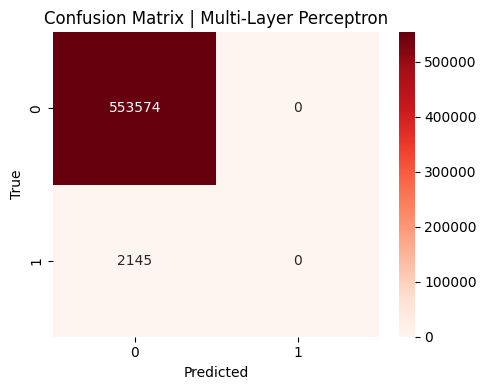

In [122]:
plt.figure(figsize=(5, 4)) 
sns.heatmap(mlp_confusion_matrix, annot=True, fmt="d", cmap="Reds") 
plt.title("Confusion Matrix | Multi-Layer Perceptron") 
plt.xlabel("Predicted")  
plt.ylabel("True") 
plt.tight_layout() 
plt.show() 